# Exponential Distribution

The **Exponential distribution** models the waiting time between events in a Poisson process, or the lifetime of a component with a constant failure rate. Its defining feature is the **memoryless property**: given survival to time t, the remaining lifetime has the same distribution as the original.

| Property | Value |
|---|---|
| **Parameters** | $\beta$ (scale, $\beta > 0$); optional $\mu$ (location) |
| **Support** | $[\mu, +\infty)$ |
| **PDF** | $f(x) = \dfrac{1}{\beta} \exp\!\left(-\dfrac{x-\mu}{\beta}\right)$ |
| **CDF** | $F(x) = 1 - \exp\!\left(-\dfrac{x-\mu}{\beta}\right)$ |
| **Mean** | $\mu + \beta$ |
| **Median** | $\mu + \beta \ln 2$ |
| **Mode** | $\mu$ (always at the lower bound) |
| **Std Dev** | $\beta$ |
| **CV** | $1$ (always — mean equals std dev) |
| **Skewness** | $2$ (always right-skewed) |
| **Hazard** | $1/\beta = \text{constant}$ |
| **Memoryless** | $P(X > s+t \mid X > s) = P(X > t)$ |
| **Estimation** | $\hat{\beta} = \bar{x} - \mu$ (MLE) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Exponential Distribution

### Panel 1 — PDF: Different Scale Parameters
Each curve shows the **PDF** $f(x) = (1/\beta)\exp(-x/\beta)$ for different $\beta$. All curves peak at $x=0$; a larger $\beta$ produces a flatter, slower-decaying curve with a higher mean.

### Panel 2 — Memoryless Property
Histograms of the original Exponential sample (blue) and residual lifetimes conditional on surviving past $s=2$ (red) overlap perfectly, demonstrating: $P(X > s+t \mid X > s) = P(X > t)$. This is the **memoryless property** — the only continuous distribution with this feature.

### Panel 3 — Constant Hazard Function
Horizontal lines at $h(x) = 1/\beta$ for each $\beta$ confirm that the **instantaneous failure rate** is constant — it does not depend on age. This "random failure" mode is unique to the Exponential distribution.


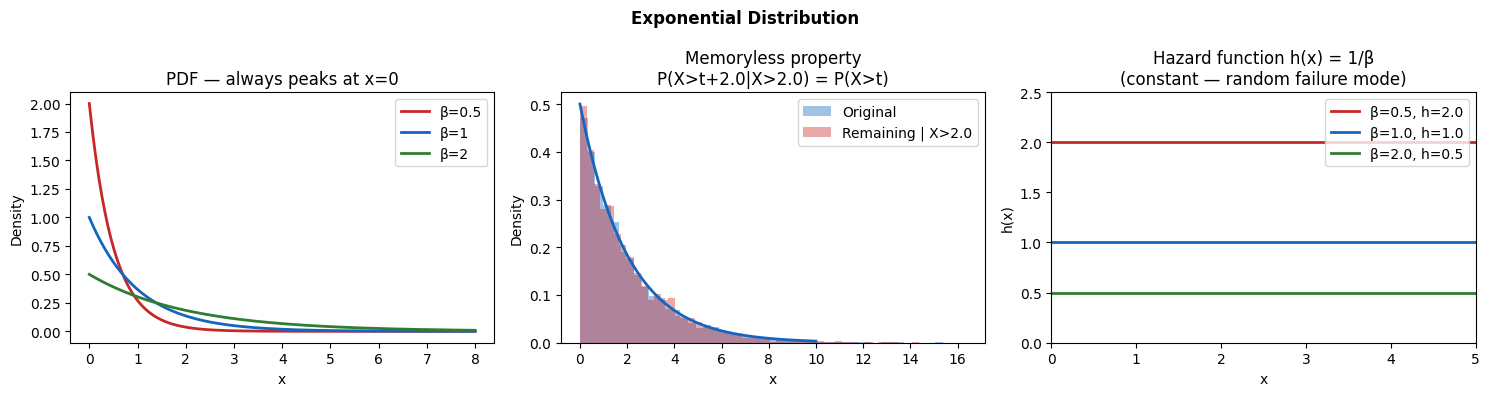

Poisson-Exponential duality:
  Poisson(λ=3): avg 3 events/unit time
  Exponential(β=1/λ=0.333): avg wait 0.333 between events


In [2]:
x = np.linspace(0, 8, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Exponential Distribution', fontsize=12, fontweight='bold')

# PDF
for beta, color, label in [(0.5, '#C62828', 'β=0.5'), (1, '#1565C0', 'β=1'), (2, '#2E7D32', 'β=2')]:
    axes[0].plot(x, stats.expon(scale=beta).pdf(x), color=color, linewidth=2, label=f'β={beta}')
axes[0].set_title('PDF — always peaks at x=0')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend()

# Memoryless property demonstration
np.random.seed(42)
beta = 2.0
data = stats.expon(scale=beta).rvs(10000)
s = 2.0  # conditioning threshold
remaining = data[data > s] - s  # remaining lifetimes given survival past s

x_range = np.linspace(0, 10, 300)
axes[1].hist(data, bins=50, density=True, alpha=0.4, color='#1565C0', label='Original')
axes[1].hist(remaining, bins=50, density=True, alpha=0.4, color='#C62828', label=f'Remaining | X>{s}')
axes[1].plot(x_range, stats.expon(scale=beta).pdf(x_range), color='#1565C0', linewidth=2)
axes[1].set_title(f'Memoryless property\nP(X>t+{s}|X>{s}) = P(X>t)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

# Constant hazard function
for beta, color, label in [(0.5, '#C62828', 'β=0.5, h=2.0'),
                             (1,   '#1565C0', 'β=1.0, h=1.0'),
                             (2,   '#2E7D32', 'β=2.0, h=0.5')]:
    h = 1/beta
    axes[2].axhline(h, color=color, linewidth=2, label=label)
axes[2].set_title('Hazard function h(x) = 1/β\n(constant — random failure mode)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('h(x)')
axes[2].set_xlim(0, 5); axes[2].set_ylim(0, 2.5)
axes[2].legend()

plt.tight_layout()
plt.show()

# Poisson-Exponential relationship
print("Poisson-Exponential duality:")
lam = 3  # events per unit time
print(f"  Poisson(λ={lam}): avg {lam} events/unit time")
print(f"  Exponential(β=1/λ={1/lam:.3f}): avg wait {1/lam:.3f} between events")

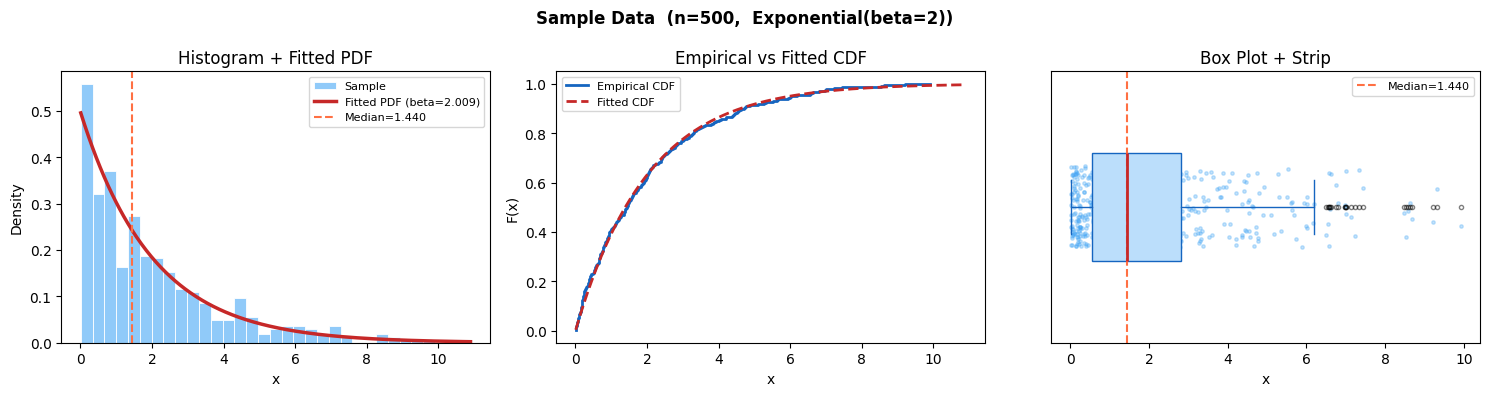

n=500  mean=2.0086  median=1.4397  std=1.9480  skew=1.4409  kurtosis=1.8544


In [3]:
# Sample data plots — Exponential(beta=2)
np.random.seed(42)
sample_d = stats.expon.rvs(scale=2, size=500)
loc_hat, scale_hat = stats.expon.fit(sample_d, floc=0)
x_fit = np.linspace(sample_d.min() * 0.9, sample_d.max() * 1.1, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Exponential(beta=2))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.expon(loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (beta={scale_hat:.3f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.expon(loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **Memoryless** | The only continuous memoryless distribution — past survival tells you nothing |
| **Constant hazard** | $h(x) = 1/\beta$ — models random (not wear-out) failures |
| **CV = 1** | Standard deviation always equals the mean |
| **Poisson link** | Inter-arrival times of a Poisson($\lambda$) process $\sim \text{Exponential}(\beta=1/\lambda)$ |
| **Estimation** | MLE: $\hat{\beta} = \bar{x}$; use if data is right-skewed with mode at 0 |
| **Use cases** | Component lifetimes (constant failure rate), queue wait times, radioactive decay |
